# Importance Sampling for AR(1) Neural Posterior Estimation

AR(1) model: $X_t = \rho X_{t-1} + \varepsilon_t$, $\varepsilon_t \sim \mathcal{N}(0, \sigma^2)$

Priors:
$$\rho \sim \text{Uniform}(-1, 1), \quad \sigma \sim \text{Uniform}(0, A)$$

The baseline estimator struggles near boundaries ($|\rho| \to 1$, $\sigma \to 0$) because uniform sampling rarely produces these cases. We use IS with Beta proposals to oversample these regions, with self-normalised weights for stable training.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import torch
import torch.nn as nn
import torch.nn.functional as nnf

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3060


## Setup

In [2]:
A = 5.0
T = 64  # time series length

n_epochs = 128
n_batches_per_epoch = 128
training_batch_size = 128
lr = 2e-3

# Fixed test set from true prior (uniform)
np.random.seed(42)
torch.manual_seed(42)
test_size = 8192
rho_test = torch.empty(test_size, device=device).uniform_(-1, 1)
sigma_test = torch.empty(test_size, device=device).uniform_(0, A)

In [3]:
def simulate_ar1_batch(rho, sigma, T, device='cpu'):
    """Simulate AR(1) with stationary initialisation."""
    batch_size = rho.shape[0]
    eps = torch.randn(batch_size, T, device=device) * sigma[:, None]
    rho_safe = torch.clamp(rho, -0.9999, 0.9999)
    x0 = torch.randn(batch_size, device=device) * sigma / torch.sqrt(1 - rho_safe**2 + 1e-8)
    x = torch.zeros(batch_size, T, device=device)
    x[:, 0] = rho * x0 + eps[:, 0]
    for t in range(1, T):
        x[:, t] = rho * x[:, t-1] + eps[:, t]
    return x

# Generate test data
x_test = simulate_ar1_batch(rho_test, sigma_test, T, device=device)
theta_test = torch.stack([rho_test, sigma_test], dim=1)
print(f"Test set: {test_size} series, shape {x_test.shape}")

Test set: 8192 series, shape torch.Size([8192, 64])


In [4]:
class GRUPosteriorEstimator(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2, mlp_hidden=128):
        super().__init__()
        self.gru = nn.GRU(input_size=input_dim, hidden_size=hidden_dim,
                          num_layers=num_layers, batch_first=True)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, mlp_hidden), nn.ReLU(),
            nn.Linear(mlp_hidden, mlp_hidden), nn.ReLU(),
            nn.Linear(mlp_hidden, 32), nn.ReLU(),
            nn.Linear(32, 2))

    def forward(self, x):
        x = x.unsqueeze(-1)
        gru_out, _ = self.gru(x)
        pooled = gru_out.mean(dim=1)
        raw = self.mlp(pooled)
        rho = torch.tanh(raw[:, 0])
        sigma = torch.exp(raw[:, 1])
        return torch.stack([rho, sigma], dim=1)

## Sampling functions

In [5]:
def sample_batch_uniform(batch_size, device='cpu'):
    """Sample from the true prior: rho ~ U(-1,1), sigma ~ U(0,A)."""
    rho = torch.empty(batch_size, device=device).uniform_(-1, 1)
    sigma = torch.empty(batch_size, device=device).uniform_(0, A)
    return rho, sigma


def sample_batch_IS(batch_size, alpha_rho, alpha_sigma, beta_sigma=1.0, device='cpu'):
    """
    IS proposal: rho_tilde ~ Beta(alpha_rho, alpha_rho), rho = 2*rho_tilde - 1
                 sigma_tilde ~ Beta(alpha_sigma, beta_sigma), sigma = A*sigma_tilde
    
    Returns (rho, sigma, weights).
    
    Weight derivation:
      p(rho, sigma) = 1/(2A)
      q(rho, sigma) = Beta((rho+1)/2; a_rho, a_rho)/2 * Beta(sigma/A; a_sig, b_sig)/A
      w = p/q = 1 / [Beta_pdf(rho_tilde) * Beta_pdf(sigma_tilde)]
    """
    rho_tilde = np.random.beta(alpha_rho, alpha_rho, size=batch_size)
    sigma_tilde = np.random.beta(alpha_sigma, beta_sigma, size=batch_size)
    
    rho = torch.tensor(2 * rho_tilde - 1, dtype=torch.float32, device=device)
    sigma = torch.tensor(A * sigma_tilde, dtype=torch.float32, device=device)
    
    # w = p(rho,sigma) / q(rho,sigma) = 1 / [Beta_pdf(rho_tilde) * Beta_pdf(sigma_tilde)]
    q_rho = stats.beta.pdf(rho_tilde, alpha_rho, alpha_rho)
    q_sigma = stats.beta.pdf(sigma_tilde, alpha_sigma, beta_sigma)
    weights = 1.0 / (q_rho * q_sigma)
    weights = torch.tensor(weights, dtype=torch.float32, device=device)
    
    return rho, sigma, weights

## Visualise proposals

Check how different Beta parameters affect the sampling distribution and weight behaviour.

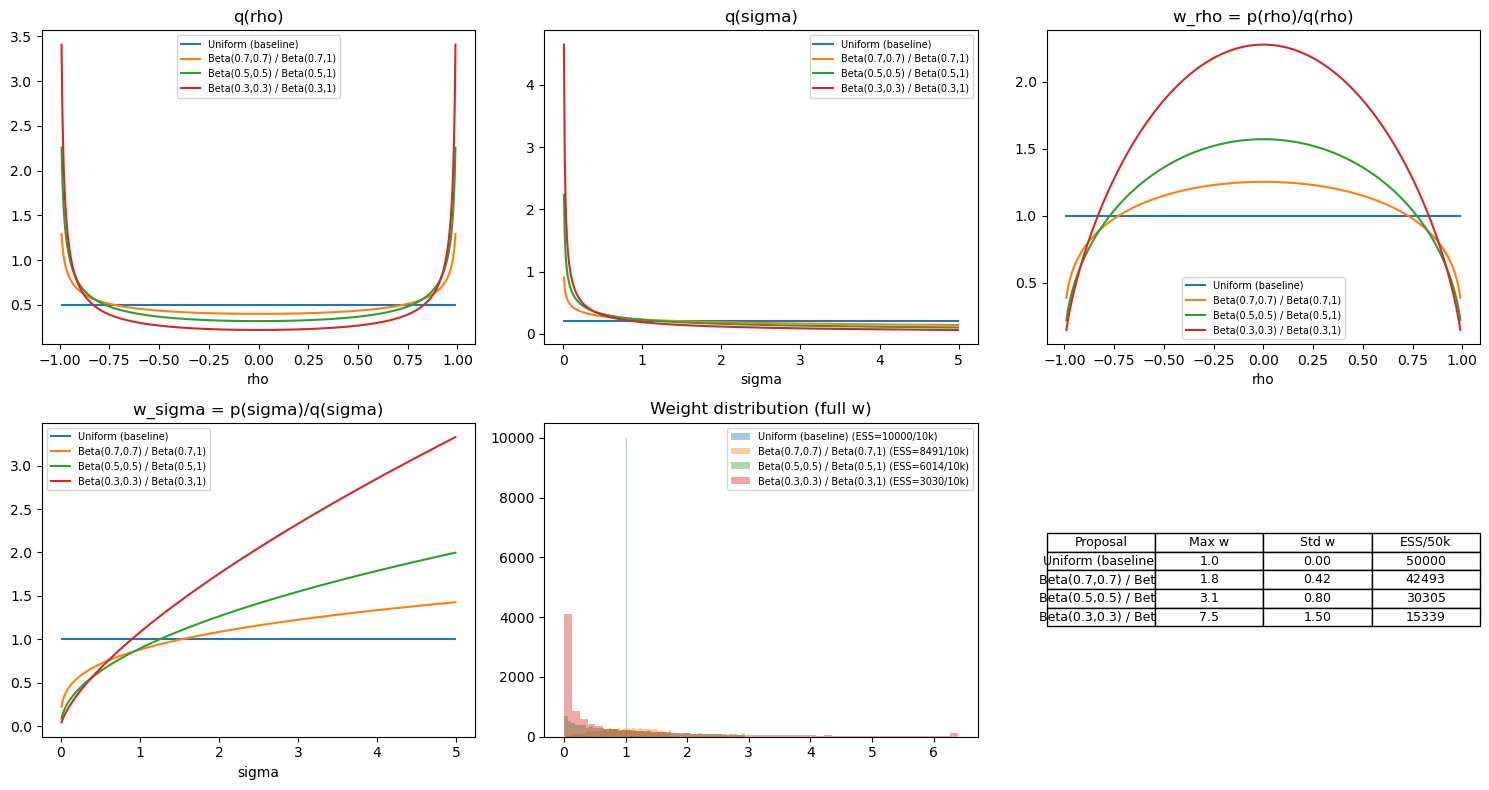

In [6]:
proposals = [
    (1.0, 1.0, 1.0, 'Uniform (baseline)'),
    (0.7, 0.7, 1.0, 'Beta(0.7,0.7) / Beta(0.7,1)'),
    (0.5, 0.5, 1.0, 'Beta(0.5,0.5) / Beta(0.5,1)'),
    (0.3, 0.3, 1.0, 'Beta(0.3,0.3) / Beta(0.3,1)'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

rho_grid = np.linspace(-0.99, 0.99, 500)
sigma_grid = np.linspace(0.01, A - 0.01, 500)
rho_tilde_grid = (rho_grid + 1) / 2
sigma_tilde_grid = sigma_grid / A

for a_rho, a_sig, b_sig, label in proposals:
    q_rho = stats.beta.pdf(rho_tilde_grid, a_rho, a_rho) / 2
    q_sig = stats.beta.pdf(sigma_tilde_grid, a_sig, b_sig) / A
    
    w_rho = (1/2) / q_rho  # marginal weight for rho
    w_sig = (1/A) / q_sig  # marginal weight for sigma
    
    axes[0, 0].plot(rho_grid, q_rho, label=label)
    axes[0, 1].plot(sigma_grid, q_sig, label=label)
    axes[0, 2].plot(rho_grid, w_rho, label=label)
    axes[1, 0].plot(sigma_grid, w_sig, label=label)
    
    # Sample and show weight distribution
    np.random.seed(0)
    _, _, w = sample_batch_IS(10000, a_rho, a_sig, b_sig)
    w_np = w.numpy()
    ess = (w_np.sum()**2) / (w_np**2).sum()
    axes[1, 1].hist(np.clip(w_np, 0, np.percentile(w_np, 99)), bins=50,
                    alpha=0.4, label=f'{label} (ESS={ess:.0f}/10k)')

axes[0, 0].set_title('q(rho)'); axes[0, 0].set_xlabel('rho'); axes[0, 0].legend(fontsize=7)
axes[0, 1].set_title('q(sigma)'); axes[0, 1].set_xlabel('sigma'); axes[0, 1].legend(fontsize=7)
axes[0, 2].set_title('w_rho = p(rho)/q(rho)'); axes[0, 2].set_xlabel('rho'); axes[0, 2].legend(fontsize=7)
axes[1, 0].set_title('w_sigma = p(sigma)/q(sigma)'); axes[1, 0].set_xlabel('sigma'); axes[1, 0].legend(fontsize=7)
axes[1, 1].set_title('Weight distribution (full w)'); axes[1, 1].legend(fontsize=7)

# Max weights table
ax = axes[1, 2]
ax.axis('off')
rows = []
for a_rho, a_sig, b_sig, label in proposals:
    np.random.seed(0)
    _, _, w = sample_batch_IS(50000, a_rho, a_sig, b_sig)
    w_np = w.numpy()
    ess = (w_np.sum()**2) / (w_np**2).sum()
    rows.append([label[:20], f'{w_np.max():.1f}', f'{w_np.std():.2f}', f'{ess:.0f}'])
table = ax.table(cellText=rows, colLabels=['Proposal', 'Max w', 'Std w', 'ESS/50k'],
                 loc='center', cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(9)

plt.tight_layout(); plt.show()

## Training

In [7]:
loss_fn = nn.MSELoss()

def train_baseline(seed=0):
    """Train with uniform sampling (standard MSE loss)."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = GRUPosteriorEstimator().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    test_losses = []

    for epoch in range(n_epochs):
        model.train()
        for _ in range(n_batches_per_epoch):
            rho, sigma = sample_batch_uniform(training_batch_size, device=device)
            x = simulate_ar1_batch(rho, sigma, T, device=device)
            if torch.isnan(x).any():
                continue

            optimizer.zero_grad()
            pred = model(x)
            loss = loss_fn(pred, torch.stack([rho, sigma], dim=1))
            if torch.isnan(loss):
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        with torch.no_grad():
            test_losses.append(loss_fn(model(x_test), theta_test).item())
        if (epoch + 1) % 16 == 0:
            print(f"  Baseline epoch {epoch+1}/{n_epochs}, Test MSE: {test_losses[-1]:.4f}")

    return model, test_losses


def train_IS(alpha_rho, alpha_sigma, beta_sigma=1.0, seed=0):
    """Train with IS proposal, self-normalised weighted MSE loss."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = GRUPosteriorEstimator().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    test_losses = []

    for epoch in range(n_epochs):
        model.train()
        for _ in range(n_batches_per_epoch):
            rho, sigma, weights = sample_batch_IS(
                training_batch_size, alpha_rho, alpha_sigma, beta_sigma, device=device)
            x = simulate_ar1_batch(rho, sigma, T, device=device)
            if torch.isnan(x).any():
                continue

            optimizer.zero_grad()
            pred = model(x)
            sq_err = ((pred - torch.stack([rho, sigma], dim=1)) ** 2).sum(dim=1)

            # Self-normalised IS loss
            loss = (weights * sq_err).sum() / weights.sum()
            if torch.isnan(loss):
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        with torch.no_grad():
            test_losses.append(loss_fn(model(x_test), theta_test).item())
        if (epoch + 1) % 16 == 0:
            print(f"  IS(a_rho={alpha_rho}, a_sig={alpha_sigma}) epoch {epoch+1}/{n_epochs}, Test MSE: {test_losses[-1]:.4f}")

    return model, test_losses

In [8]:
print("Training baseline (uniform)...")
model_base, losses_base = train_baseline(seed=0)

print("\nTraining IS alpha=0.7...")
model_is07, losses_is07 = train_IS(0.7, 0.7, 1.0, seed=0)

print("\nTraining IS alpha=0.5...")
model_is05, losses_is05 = train_IS(0.5, 0.5, 1.0, seed=0)

print("\nTraining IS alpha=0.3...")
model_is03, losses_is03 = train_IS(0.3, 0.3, 1.0, seed=0)

Training baseline (uniform)...
  Baseline epoch 16/128, Test MSE: 0.0618
  Baseline epoch 32/128, Test MSE: 0.0416
  Baseline epoch 48/128, Test MSE: 0.0408
  Baseline epoch 64/128, Test MSE: 0.0387
  Baseline epoch 80/128, Test MSE: 0.0350
  Baseline epoch 96/128, Test MSE: 0.0377
  Baseline epoch 112/128, Test MSE: 0.0367
  Baseline epoch 128/128, Test MSE: 0.0368

Training IS alpha=0.7...
  IS(a_rho=0.7, a_sig=0.7) epoch 16/128, Test MSE: 0.0532
  IS(a_rho=0.7, a_sig=0.7) epoch 32/128, Test MSE: 0.0497
  IS(a_rho=0.7, a_sig=0.7) epoch 48/128, Test MSE: 0.0413
  IS(a_rho=0.7, a_sig=0.7) epoch 64/128, Test MSE: 0.0381
  IS(a_rho=0.7, a_sig=0.7) epoch 80/128, Test MSE: 0.0374
  IS(a_rho=0.7, a_sig=0.7) epoch 96/128, Test MSE: 0.0537
  IS(a_rho=0.7, a_sig=0.7) epoch 112/128, Test MSE: 0.0373
  IS(a_rho=0.7, a_sig=0.7) epoch 128/128, Test MSE: 0.0399

Training IS alpha=0.5...
  IS(a_rho=0.5, a_sig=0.5) epoch 16/128, Test MSE: 0.0514
  IS(a_rho=0.5, a_sig=0.5) epoch 32/128, Test MSE: 0.04

## Test loss curves

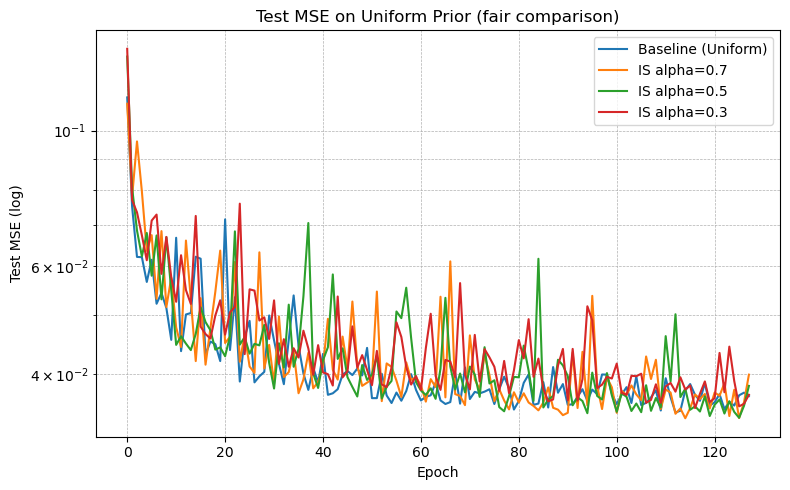

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(losses_base, label='Baseline (Uniform)')
plt.plot(losses_is07, label='IS alpha=0.7')
plt.plot(losses_is05, label='IS alpha=0.5')
plt.plot(losses_is03, label='IS alpha=0.3')
plt.yscale('log')
plt.xlabel('Epoch'); plt.ylabel('Test MSE (log)')
plt.title('Test MSE on Uniform Prior (fair comparison)')
plt.legend(); plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout(); plt.show()

## MSE breakdown by (rho, sigma) bins

The key diagnostic: does IS help in the boundary regions?

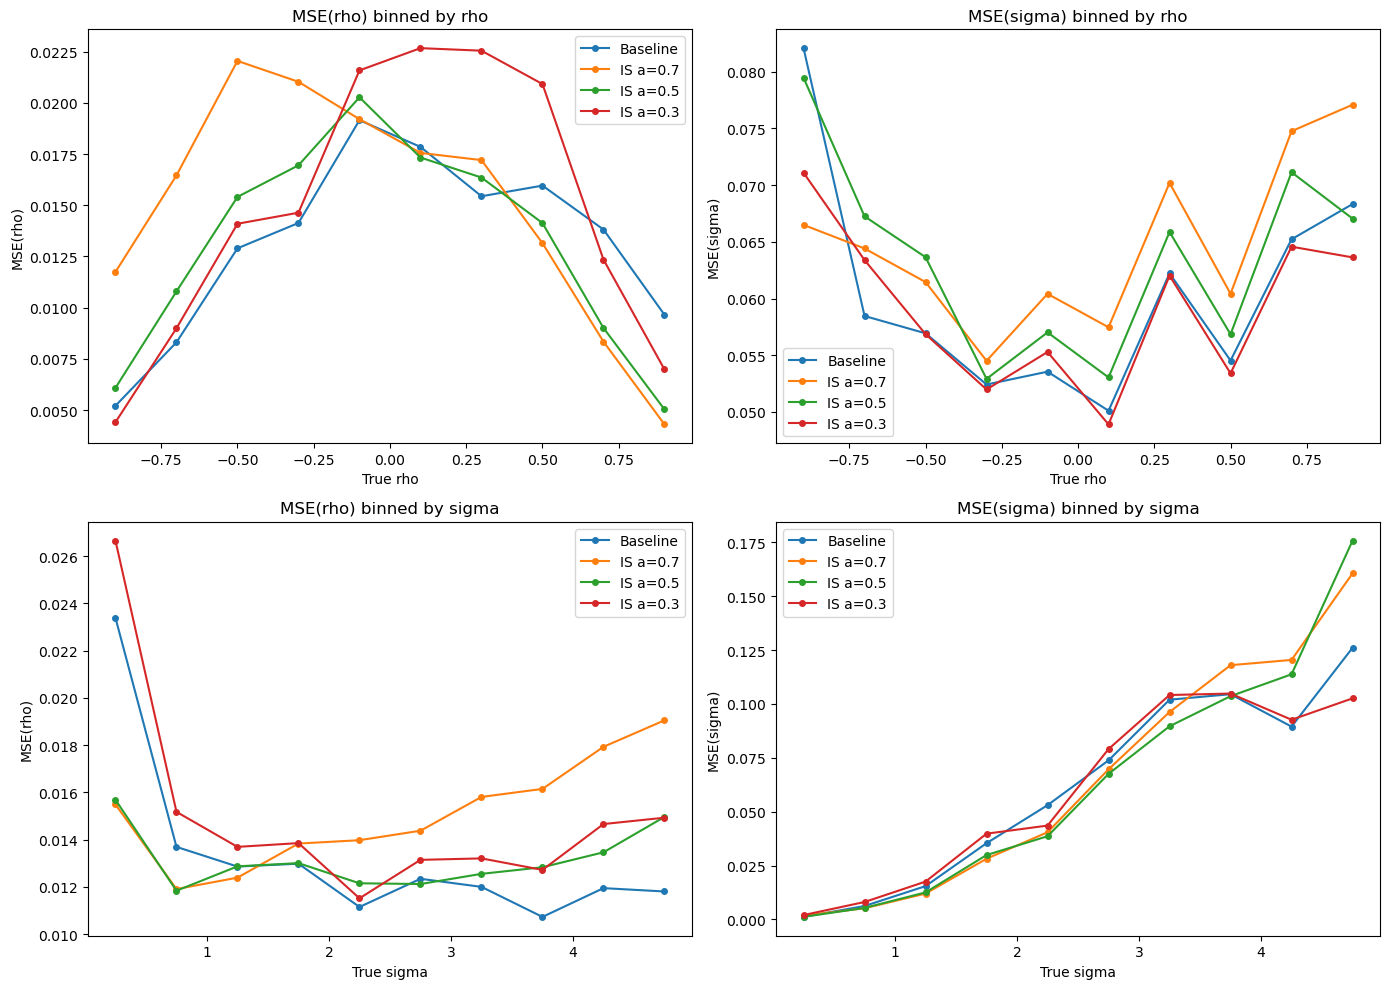

In [10]:
models = {
    'Baseline': model_base,
    'IS a=0.7': model_is07,
    'IS a=0.5': model_is05,
    'IS a=0.3': model_is03,
}

def compute_binned_mse_1d(model, x_test, theta_test, param_idx, n_bins=10):
    """MSE for rho and sigma, binned by one parameter."""
    with torch.no_grad():
        pred = model(x_test).cpu().numpy()
    true = theta_test.cpu().numpy()
    
    param_true = true[:, param_idx]
    lo, hi = (-1, 1) if param_idx == 0 else (0, A)
    bin_edges = np.linspace(lo, hi, n_bins + 1)
    bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    mse_rho = np.zeros(n_bins)
    mse_sigma = np.zeros(n_bins)
    
    for b in range(n_bins):
        mask = (param_true >= bin_edges[b]) & (param_true < bin_edges[b+1])
        if mask.sum() == 0:
            continue
        mse_rho[b] = np.mean((pred[mask, 0] - true[mask, 0])**2)
        mse_sigma[b] = np.mean((pred[mask, 1] - true[mask, 1])**2)
    
    return bin_centres, mse_rho, mse_sigma


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Row 0: binned by rho
for name, model in models.items():
    centres, mse_rho, mse_sigma = compute_binned_mse_1d(model, x_test, theta_test, param_idx=0)
    axes[0, 0].plot(centres, mse_rho, 'o-', label=name, markersize=4)
    axes[0, 1].plot(centres, mse_sigma, 'o-', label=name, markersize=4)

axes[0, 0].set_xlabel('True rho'); axes[0, 0].set_ylabel('MSE(rho)')
axes[0, 0].set_title('MSE(rho) binned by rho'); axes[0, 0].legend()
axes[0, 1].set_xlabel('True rho'); axes[0, 1].set_ylabel('MSE(sigma)')
axes[0, 1].set_title('MSE(sigma) binned by rho'); axes[0, 1].legend()

# Row 1: binned by sigma
for name, model in models.items():
    centres, mse_rho, mse_sigma = compute_binned_mse_1d(model, x_test, theta_test, param_idx=1)
    axes[1, 0].plot(centres, mse_rho, 'o-', label=name, markersize=4)
    axes[1, 1].plot(centres, mse_sigma, 'o-', label=name, markersize=4)

axes[1, 0].set_xlabel('True sigma'); axes[1, 0].set_ylabel('MSE(rho)')
axes[1, 0].set_title('MSE(rho) binned by sigma'); axes[1, 0].legend()
axes[1, 1].set_xlabel('True sigma'); axes[1, 1].set_ylabel('MSE(sigma)')
axes[1, 1].set_title('MSE(sigma) binned by sigma'); axes[1, 1].legend()

plt.tight_layout(); plt.show()

## 2D MSE heatmaps

Spatially see where each model does well/poorly in the $(\rho, \sigma)$ plane.

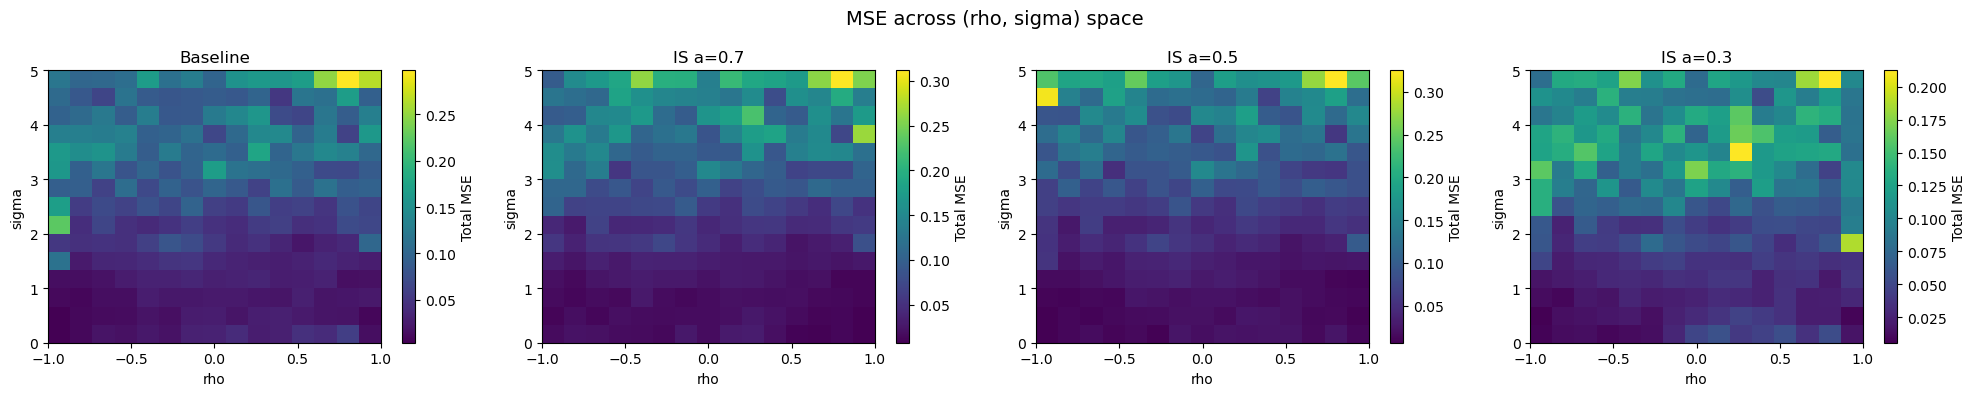

In [11]:
n_bins_2d = 15
rho_edges = np.linspace(-1, 1, n_bins_2d + 1)
sig_edges = np.linspace(0, A, n_bins_2d + 1)

true_np = theta_test.cpu().numpy()
ri = np.clip(np.digitize(true_np[:, 0], rho_edges) - 1, 0, n_bins_2d - 1)
si = np.clip(np.digitize(true_np[:, 1], sig_edges) - 1, 0, n_bins_2d - 1)

fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))

for idx, (name, model) in enumerate(models.items()):
    with torch.no_grad():
        pred = model(x_test).cpu().numpy()
    total_sq_err = ((pred - true_np) ** 2).sum(axis=1)
    
    grid = np.full((n_bins_2d, n_bins_2d), np.nan)
    for r in range(n_bins_2d):
        for s in range(n_bins_2d):
            mask = (ri == r) & (si == s)
            if mask.sum() > 2:
                grid[s, r] = np.mean(total_sq_err[mask])
    
    im = axes[idx].imshow(grid, origin='lower', aspect='auto',
                          extent=[-1, 1, 0, A], cmap='viridis')
    axes[idx].set_xlabel('rho'); axes[idx].set_ylabel('sigma')
    axes[idx].set_title(name)
    plt.colorbar(im, ax=axes[idx], label='Total MSE')

plt.suptitle('MSE across (rho, sigma) space', fontsize=14)
plt.tight_layout(); plt.show()

## Overall MSE comparison

In [12]:
print(f"{'Model':25s} {'MSE(rho)':>10s} {'MSE(sigma)':>12s} {'Total':>10s}")
print('-' * 59)

for name, model in models.items():
    with torch.no_grad():
        pred = model(x_test).cpu().numpy()
    true = theta_test.cpu().numpy()
    mse_rho = np.mean((pred[:, 0] - true[:, 0])**2)
    mse_sig = np.mean((pred[:, 1] - true[:, 1])**2)
    print(f"{name:25s} {mse_rho:10.4f} {mse_sig:12.4f} {mse_rho + mse_sig:10.4f}")

Model                       MSE(rho)   MSE(sigma)      Total
-----------------------------------------------------------
Baseline                      0.0133       0.0604     0.0737
IS a=0.7                      0.0151       0.0648     0.0798
IS a=0.5                      0.0131       0.0634     0.0765
IS a=0.3                      0.0149       0.0591     0.0740


## Scatter plots: baseline vs best IS

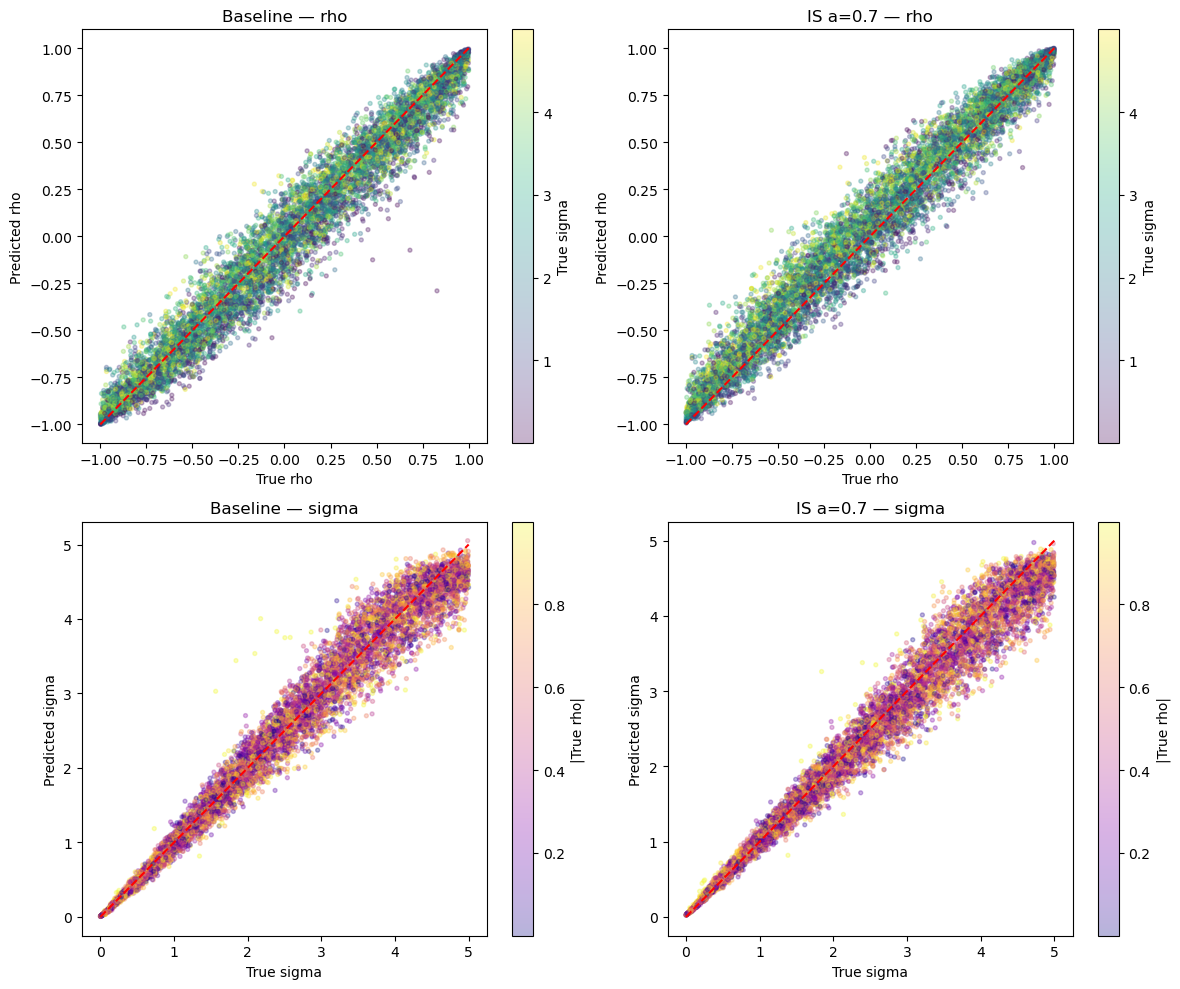

In [13]:
with torch.no_grad():
    pred_base = model_base(x_test).cpu().numpy()
    pred_best = model_is07(x_test).cpu().numpy()
true = theta_test.cpu().numpy()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for col, (name, pred) in enumerate([('Baseline', pred_base), ('IS a=0.7', pred_best)]):
    # rho predictions
    sc = axes[0, col].scatter(true[:, 0], pred[:, 0], c=true[:, 1], alpha=0.3, s=8, cmap='viridis')
    axes[0, col].plot([-1, 1], [-1, 1], 'r--')
    axes[0, col].set_xlabel('True rho'); axes[0, col].set_ylabel('Predicted rho')
    axes[0, col].set_title(f'{name} — rho')
    plt.colorbar(sc, ax=axes[0, col], label='True sigma')

    # sigma predictions
    sc = axes[1, col].scatter(true[:, 1], pred[:, 1], c=np.abs(true[:, 0]), alpha=0.3, s=8, cmap='plasma')
    axes[1, col].plot([0, A], [0, A], 'r--')
    axes[1, col].set_xlabel('True sigma'); axes[1, col].set_ylabel('Predicted sigma')
    axes[1, col].set_title(f'{name} — sigma')
    plt.colorbar(sc, ax=axes[1, col], label='|True rho|')

plt.tight_layout(); plt.show()

## Loss estimator variance analysis

For each trained model, draw $K$ independent batches from the uniform prior and measure how variable the MSE estimate is. This tells us whether IS training produced a model whose loss is easier or harder to estimate.

Model                       Mean MSE        Std    Var Ratio
-----------------------------------------------------------
Baseline                      0.0748     0.0086         1.00
IS a=0.7                      0.0821     0.0091         1.11
IS a=0.5                      0.0781     0.0088         1.04
IS a=0.3                      0.0767     0.0081         0.88


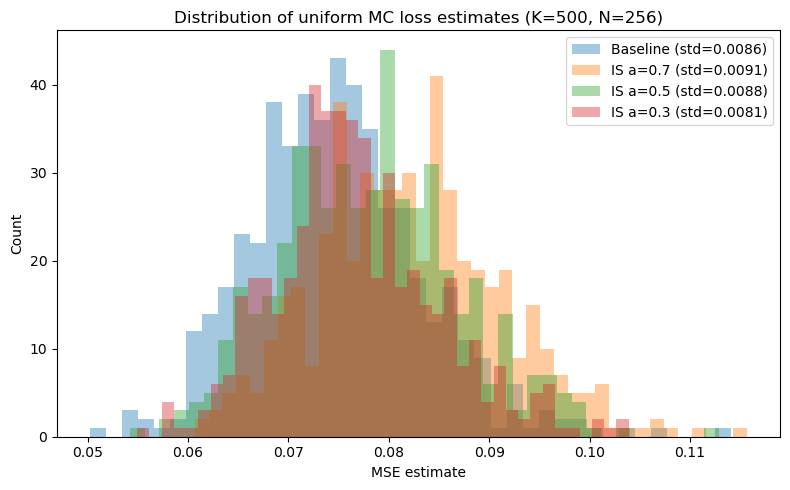

In [14]:
K = 500
N_eval = 256

np.random.seed(0)
torch.manual_seed(0)

mc_estimates = {}

for name, model in models.items():
    model.eval()
    estimates = []
    for _ in range(K):
        rho = torch.empty(N_eval, device=device).uniform_(-1, 1)
        sigma = torch.empty(N_eval, device=device).uniform_(0, A)
        x = simulate_ar1_batch(rho, sigma, T, device=device)
        with torch.no_grad():
            pred = model(x)
        mse = ((pred - torch.stack([rho, sigma], dim=1))**2).sum(dim=1).mean().item()
        estimates.append(mse)
    mc_estimates[name] = np.array(estimates)

# Table
ref_var = mc_estimates['Baseline'].var()
print(f"{'Model':25s} {'Mean MSE':>10s} {'Std':>10s} {'Var Ratio':>12s}")
print('-' * 59)
for name in models:
    est = mc_estimates[name]
    ratio = est.var() / ref_var
    print(f"{name:25s} {est.mean():10.4f} {est.std():10.4f} {ratio:12.2f}")

# Histograms
fig, ax = plt.subplots(figsize=(8, 5))
for name in models:
    ax.hist(mc_estimates[name], bins=40, alpha=0.4, label=f"{name} (std={mc_estimates[name].std():.4f})")
ax.set_xlabel('MSE estimate'); ax.set_ylabel('Count')
ax.set_title(f'Distribution of uniform MC loss estimates (K={K}, N={N_eval})')
ax.legend(); plt.tight_layout(); plt.show()